In [36]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp
from torchvision.models.optical_flow import raft_small, Raft_Small_Weights
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json
import random
import time
from PIL import ImageFilter, ImageChops

In [174]:
SAVE_ROOT = 'output_frames'
os.makedirs(SAVE_ROOT, exist_ok=True)

def save_frame(model_tag, video_idx, frame_idx_in_video, img_np, mask_pred, save_root=SAVE_ROOT, extra_mask=None, extra_tag=None):
    out_dir = os.path.join(save_root, model_tag, f'video_{video_idx:03d}')
    os.makedirs(out_dir, exist_ok=True)

    img_uint8 = (img_np * 255).clip(0, 255).astype(np.uint8) if img_np.max() <= 1.5 else img_np.astype(np.uint8)
    overlay = img_uint8.copy()
    overlay[mask_pred > 0.5] = (
        0.5 * overlay[mask_pred > 0.5] + 0.5 * np.array([255, 0, 0])
    ).astype(np.uint8)
    Image.fromarray(overlay).save(os.path.join(out_dir, f'frame_{frame_idx_in_video:04d}.png'))

    if extra_mask is not None and extra_tag is not None:
        extra_overlay = img_uint8.copy()
        extra_overlay[extra_mask > 0.5] = (
            0.5 * extra_overlay[extra_mask > 0.5] + 0.5 * np.array([0, 255, 0])
        ).astype(np.uint8)
        Image.fromarray(extra_overlay).save(os.path.join(out_dir, f'{extra_tag}_{frame_idx_in_video:04d}.png'))

In [16]:
def corrupt_prev_mask(mask_img):
    kind = random.choices(
        ['none', 'erode', 'dilate', 'shift', 'drop'],
        weights=[0.35, 0.15, 0.15, 0.2, 0.15]
    )[0]

    if kind == 'none':
        return mask_img
    elif kind == 'erode':
        size = random.choice([3, 5, 7])
        return mask_img.filter(ImageFilter.MinFilter(size))
    elif kind == 'dilate':
        size = random.choice([3, 5, 7])
        return mask_img.filter(ImageFilter.MaxFilter(size))
    elif kind == 'shift':
        dx = random.randint(-15, 15)
        dy = random.randint(-15, 15)
        return ImageChops.offset(mask_img, dx, dy)
    elif kind == 'drop':
        return Image.new('L', mask_img.size, 0)

In [17]:
class YVOSDataset(Dataset):
    def __init__(self,
                 path,
                 length,
                 transform_img=None,
                 transform_mask=None,
                 shuffle=True,
                 seed=12,
                 corrupt_prev_mask_aug=False,
                 use_flow_mask=False,
                 save_flow_masks=False,
                 flow_masks_dir=None,
                 raft_model=None,
                 raft_device=None):

        self.path = path
        self.transform_img = transform_img
        self.transform_mask = transform_mask
        self.corrupt_prev_mask_aug = corrupt_prev_mask_aug

        self.use_flow_mask = use_flow_mask
        self.save_flow_masks = save_flow_masks
        self.flow_masks_dir = flow_masks_dir
        self.raft_model = raft_model
        self.raft_device = raft_device

        self.data = []
        with open(os.path.join(self.path, 'meta.json'), 'r') as f:
            file = json.load(f)
            video_ids = list(file['videos'].keys())
            for video in video_ids:
                if '1' not in file['videos'][video]['objects']:
                    continue
                frames = file['videos'][video]['objects']['1']['frames']
                for i in range(len(frames)):
                    if i == 0:
                        self.data.append((
                            os.path.join(self.path, f'JPEGImages/{video}/{frames[i]}.jpg'),
                            None, 
                            None,
                            os.path.join(self.path, f'Annotations/{video}/{frames[i]}.png')
                        ))
                    else:
                        self.data.append((
                            os.path.join(self.path, f'JPEGImages/{video}/{frames[i]}.jpg'),
                            os.path.join(self.path, f'JPEGImages/{video}/{frames[i-1]}.jpg'),
                            os.path.join(self.path, f'Annotations/{video}/{frames[i-1]}.png'),
                            os.path.join(self.path, f'Annotations/{video}/{frames[i]}.png')
                        ))

        if shuffle:
            random.Random(seed).shuffle(self.data)

        self.data = self.data[:min(length, len(self.data))]
        self.len_dataset = len(self.data)

        if self.save_flow_masks and self.use_flow_mask:
            self._precompute_flow_masks()

    def _flow_mask_path(self, path_img):
        rel = os.path.relpath(path_img, self.path)           
        rel_no_ext = os.path.splitext(rel)[0]         
        return os.path.join(self.flow_masks_dir, rel_no_ext + '.npy')

    def _precompute_flow_masks(self):
        os.makedirs(self.flow_masks_dir, exist_ok=True)
        skipped = 0
        processed = 0
        t0 = time.time()

        for i, (path_img, path_prev_img, path_prev_mask, path_mask) in enumerate(self.data):
            save_path = self._flow_mask_path(path_img)

            if os.path.exists(save_path):
                skipped += 1
                continue

            if path_prev_img is None:
                img = Image.open(path_img)
                W, H = img.size
                flow_mask = np.zeros((H, W), dtype=np.float32)
            else:
                frame1 = Image.open(path_prev_img)
                frame2 = Image.open(path_img)

                prev_mask_pil = Image.open(path_prev_mask)
                prev_mask_np = np.array(prev_mask_pil)
                prev_mask_binary = (prev_mask_np == 1).astype(np.float32)

                flow_mask = warp_mask_with_flow(
                    prev_mask_binary, frame1, frame2,
                    self.raft_model, self.raft_device
                )

            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            np.save(save_path, flow_mask.astype(np.float32))
            processed += 1

            if (i + 1) % 100 == 0:
                elapsed = time.time() - t0
                rate = (processed + skipped) / elapsed
                remaining = (self.len_dataset - i - 1) / rate if rate > 0 else 0
                print(f"  [{i+1}/{self.len_dataset}] "
                      f"processed={processed} skiped={skipped} "
                      f"~{remaining/60:.1f} mins more")

        elapsed = time.time() - t0
        print(f"[flow] done by time {elapsed/60:.1f} min "
              f"new: {processed}, from cash: {skipped}.")

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        path_img, path_prev_img, path_prev_mask, path_mask = self.data[index]
        img = Image.open(path_img)
        mask = Image.open(path_mask)

        mask_np = np.array(mask)
        mask_binary = (mask_np == 1).astype(np.uint8) * 255
        mask = Image.fromarray(mask_binary, mode='L')

        if self.use_flow_mask:
            prev_mask = self._get_flow_prev_mask(path_img, path_prev_img, path_prev_mask)
        else:
            if path_prev_mask is None:
                prev_mask = Image.fromarray(
                    np.zeros(mask_np.shape, dtype=np.uint8), mode='L'
                )
            else:
                pm = Image.open(path_prev_mask)
                pm_np = np.array(pm)
                pm_binary = (pm_np == 1).astype(np.uint8) * 255
                prev_mask = Image.fromarray(pm_binary, mode='L')
                if self.corrupt_prev_mask_aug:
                    prev_mask = corrupt_prev_mask(prev_mask)

        if self.transform_img is not None:
            img = self.transform_img(img)
        if self.transform_mask is not None:
            mask = self.transform_mask(mask)
            prev_mask = self.transform_mask(prev_mask)

        return img, prev_mask, mask

    def _get_flow_prev_mask(self, path_img, path_prev_img, path_prev_mask):
        if path_prev_img is None:
            img = Image.open(path_img)
            W, H = img.size
            return Image.fromarray(np.zeros((H, W), dtype=np.uint8), mode='L')

        if self.save_flow_masks and self.flow_masks_dir is not None:
            npy_path = self._flow_mask_path(path_img)
            if os.path.exists(npy_path):
                flow_mask = np.load(npy_path)
                flow_mask_u8 = (flow_mask * 255).clip(0, 255).astype(np.uint8)
                return Image.fromarray(flow_mask_u8, mode='L')

        frame1 = Image.open(path_prev_img)
        frame2 = Image.open(path_img)

        pm = Image.open(path_prev_mask)
        pm_np = np.array(pm)
        prev_mask_binary = (pm_np == 1).astype(np.float32)

        flow_mask = warp_mask_with_flow(
            prev_mask_binary, frame1, frame2,
            self.raft_model, self.raft_device
        )
        flow_mask_u8 = (flow_mask * 255).clip(0, 255).astype(np.uint8)
        return Image.fromarray(flow_mask_u8, mode='L')

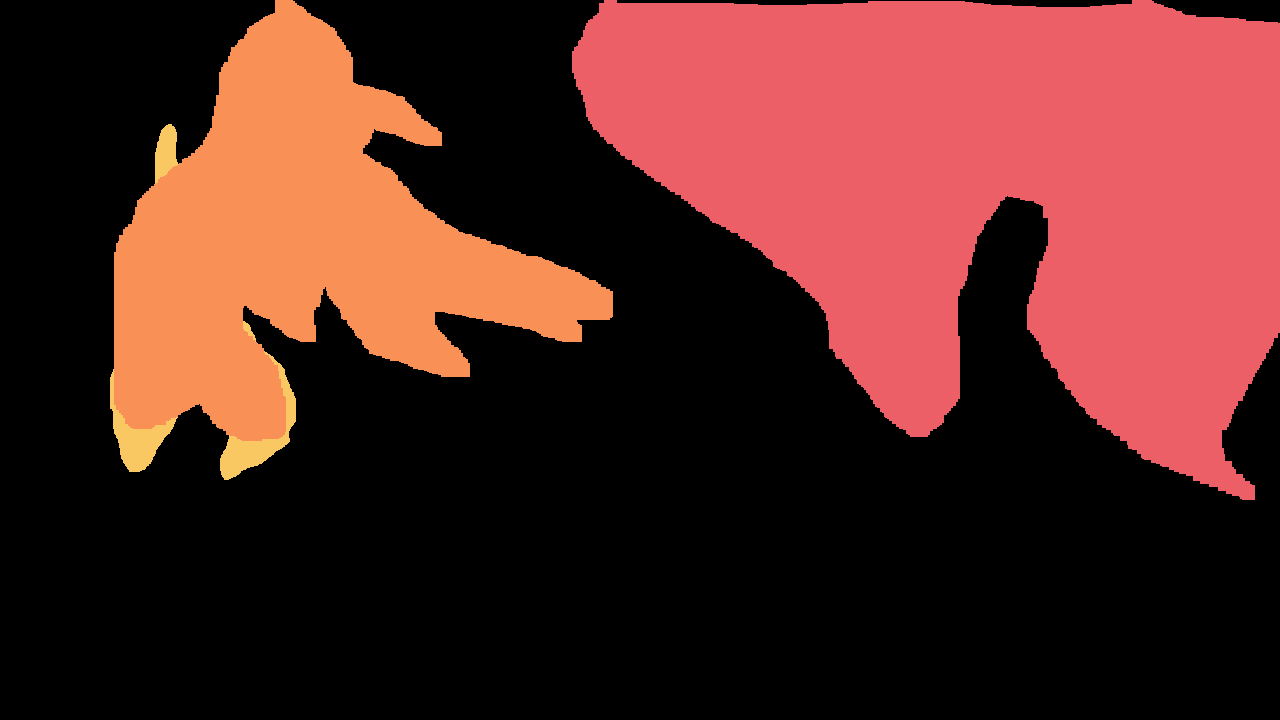

In [140]:
mask = Image.open('../data/YoutubeVos/train/Annotations/0a8c467cc3/00000.png')
mask

In [14]:
mask_np = np.array(mask)
np.unique(mask_np)

array([0, 1, 2, 3], dtype=uint8)

In [24]:
len(train)

10

In [170]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

In [171]:
model1 = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=4,
    classes=1,
    activation='sigmoid'
)

model1.eval()

device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f'model1 loaded to {device}')

model1 loaded to mps


In [65]:
def predict_mask(model, img, prev_mask=None, 
                 transform_img=None, transform_mask=None, device='cpu'):

    if isinstance(img, np.ndarray):
        img = Image.fromarray((img * 255).astype(np.uint8))
        
    if transform_img is not None:
        img = transform_img(img)
    img_tensor = img.unsqueeze(0)

    if prev_mask is None:
        prev_mask_tensor = torch.zeros(1, 1, 256, 256)
    else:
        if isinstance(prev_mask, np.ndarray):
            prev_mask = Image.fromarray(prev_mask)
        
        if transform_mask is not None:
            prev_mask = transform_mask(prev_mask)
        prev_mask_tensor = prev_mask.unsqueeze(0)

    input_tensor = torch.cat([img_tensor, prev_mask_tensor], dim=1)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        output = model(input_tensor)
        mask_pred = (output > 0.5).float().squeeze().cpu().numpy()
        
    return mask_pred

In [66]:
def calculate_metrics(mask_pred, mask_gt):
    mask_pred = (mask_pred > 0.5).astype(np.uint8)
    mask_gt = (mask_gt > 0.5).astype(np.uint8)
    
    tp = np.sum((mask_pred == 1) & (mask_gt == 1))
    fp = np.sum((mask_pred == 1) & (mask_gt == 0))
    tn = np.sum((mask_pred == 0) & (mask_gt == 0))
    fn = np.sum((mask_pred == 0) & (mask_gt == 1))

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

    return {
        'accuracy': accuracy,
        'iou': iou, 
        'dice': dice,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn
    }

In [26]:
transform_img = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_prev = YVOSDataset(
    path='../data/YoutubeVos/train',
    length=4000,
    transform_img=transform_img,
    transform_mask=transform_mask,
    shuffle=True, seed=10,
    corrupt_prev_mask_aug=True,
    use_flow_mask=False,
)

In [25]:
transform_mask = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor()
])
valid_prev = YVOSDataset(
    path='../data/YoutubeVos/valid',
    length=200,
    transform_img=transform_img,
    transform_mask=transform_mask,
    shuffle=False,
    use_flow_mask=False,
)

In [92]:
train_prev[1]

(tensor([[[1.1015, 1.3584, 1.7694,  ..., 1.0502, 1.2385, 1.3242],
          [1.1700, 1.3242, 1.6324,  ..., 0.4851, 0.5364, 0.6049],
          [1.2728, 1.3755, 1.4783,  ..., 0.7248, 0.7591, 0.8276],
          ...,
          [0.5878, 0.6221, 0.8789,  ..., 0.7248, 0.7591, 0.5022],
          [0.6049, 0.7419, 0.8447,  ..., 0.5707, 0.5193, 0.5193],
          [0.5707, 0.6563, 0.4337,  ..., 0.5364, 0.4851, 0.5707]],
 
         [[1.6408, 0.9405, 0.2752,  ..., 1.0630, 1.2731, 1.3606],
          [1.7808, 1.1681, 0.5378,  ..., 0.4328, 0.4853, 0.5378],
          [1.9559, 1.5882, 0.9055,  ..., 0.6078, 0.6429, 0.7129],
          ...,
          [0.7479, 0.7829, 1.0455,  ..., 1.1155, 1.1506, 0.8880],
          [0.7654, 0.9055, 1.0105,  ..., 0.9580, 0.9055, 0.9055],
          [0.7304, 0.8179, 0.5903,  ..., 0.9055, 0.8704, 0.9580]],
 
         [[2.5703, 2.1171, 1.5594,  ..., 1.2457, 1.4548, 1.5594],
          [2.5877, 2.2043, 1.6814,  ..., 0.6356, 0.6879, 0.7576],
          [2.6051, 2.4134, 1.8731,  ...,

In [151]:
test_loader = DataLoader(valid_prev, batch_size=1, shuffle=False)
results = []
prev_mask_pred = None 
for idx, (img, prev_mask, mask_gt) in enumerate(test_loader):
    img_np = img.squeeze().permute(1, 2, 0).numpy()
    mask_gt_np = mask_gt.squeeze().numpy()
    
    if (prev_mask == 0).all().item():
        prev_mask_pred = mask_gt_np

    mask_pred = predict_mask(model1, img_np, prev_mask_pred,
                             transform_img=transform_img, transform_mask=transform_mask)
    results.append({
        'idx': idx,
        'img': img_np,
        'prev_mask': prev_mask,
        'mask_gt': mask_gt_np,
        'mask_pred': mask_pred
    })

print(f"processed {len(results)} frames")

all_metrics = []
for res in results:
    metrics = calculate_metrics(res['mask_pred'], res['mask_gt'])
    all_metrics.append(metrics)

mean_iou = np.mean([metric['iou'] for metric in all_metrics])
mean_dice = np.mean([metric['dice'] for metric in all_metrics])
mean_acc = np.mean([metric['accuracy'] for metric in all_metrics])
print('Zero-shot inference:')
print(f"mean IoU: {mean_iou:.4f}")
print(f"mean Dice: {mean_dice:.4f}")
print(f"mean Pixel Accuracy: {mean_acc:.4f}")

processed 200 frames
Zero-shot inference:
mean IoU: 0.1152
mean Dice: 0.1990
mean Pixel Accuracy: 0.1156


In [187]:
def visualize_result(results, indices, save_path=None, all_metrics=None, flow_mask_key=None):
    fig, axes = plt.subplots(len(indices), 4, figsize=(16, 4 * len(indices)))
    if len(indices) == 1:
        axes = [axes]
    for row, idx in enumerate(indices):
        img = results[idx]['img']
        mask_pred = results[idx]['mask_pred']
        mask_gt = results[idx]['mask_gt']

        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
        img_disp = img * std + mean
        img_disp = np.clip(img_disp, 0, 1)

        overlay_pred = img_disp.copy()
        overlay_pred[mask_pred > 0.5, 0] = 1.0
        overlay_pred[mask_pred > 0.5, 1] = 0.0
        overlay_pred[mask_pred > 0.5, 2] = 0.0

        axes[row][0].imshow(img_disp)
        axes[row][0].set_title(f'frame {idx}')
        axes[row][0].axis('off')

        axes[row][1].imshow(mask_gt, cmap='gray')
        axes[row][1].set_title('gt mask')
        axes[row][1].axis('off')

        iou_title = f'prediction (IoU={all_metrics[idx]["iou"]:.3f})' if all_metrics is not None else 'prediction'
        axes[row][2].imshow(mask_pred, cmap='gray')
        axes[row][2].set_title(iou_title)
        axes[row][2].axis('off')

        if flow_mask_key is not None:
            flow_mask = results[idx][flow_mask_key]
            if hasattr(flow_mask, 'numpy'):
                flow_mask = flow_mask.squeeze().numpy()
            overlay_flow = img_disp.copy()
            overlay_flow[flow_mask > 0.5, 0] = 0.0
            overlay_flow[flow_mask > 0.5, 1] = 1.0
            overlay_flow[flow_mask > 0.5, 2] = 0.0
            axes[row][3].imshow(overlay_flow)
            axes[row][3].set_title('flow mask (input)')
        else:
            axes[row][3].imshow(overlay_pred)
            axes[row][3].set_title('overlay')
        axes[row][3].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f'saved to {save_path}')
    plt.show()

saved to zero_shot_inference_result_1.png


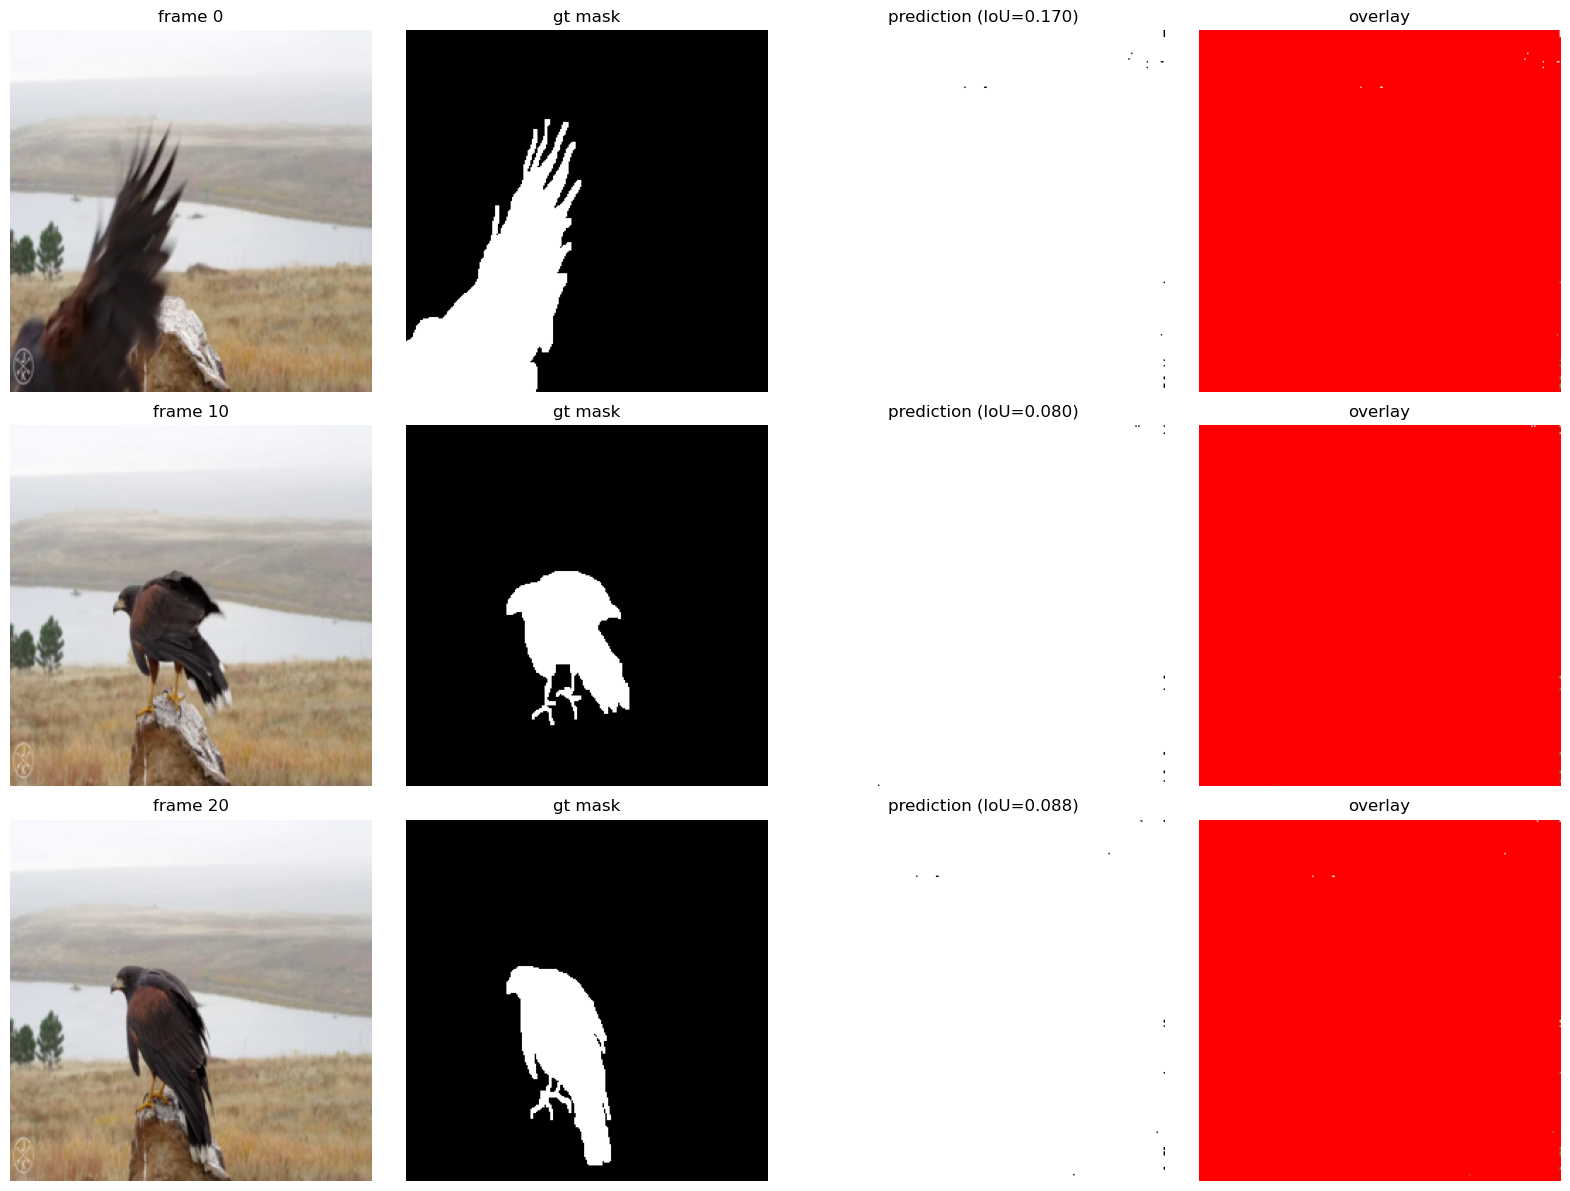

In [69]:
visualize_result(results, indices=[0, 10, 20], save_path='zero_shot_inference_result_1.png')

saved to zero_shot_inference_result_2.png


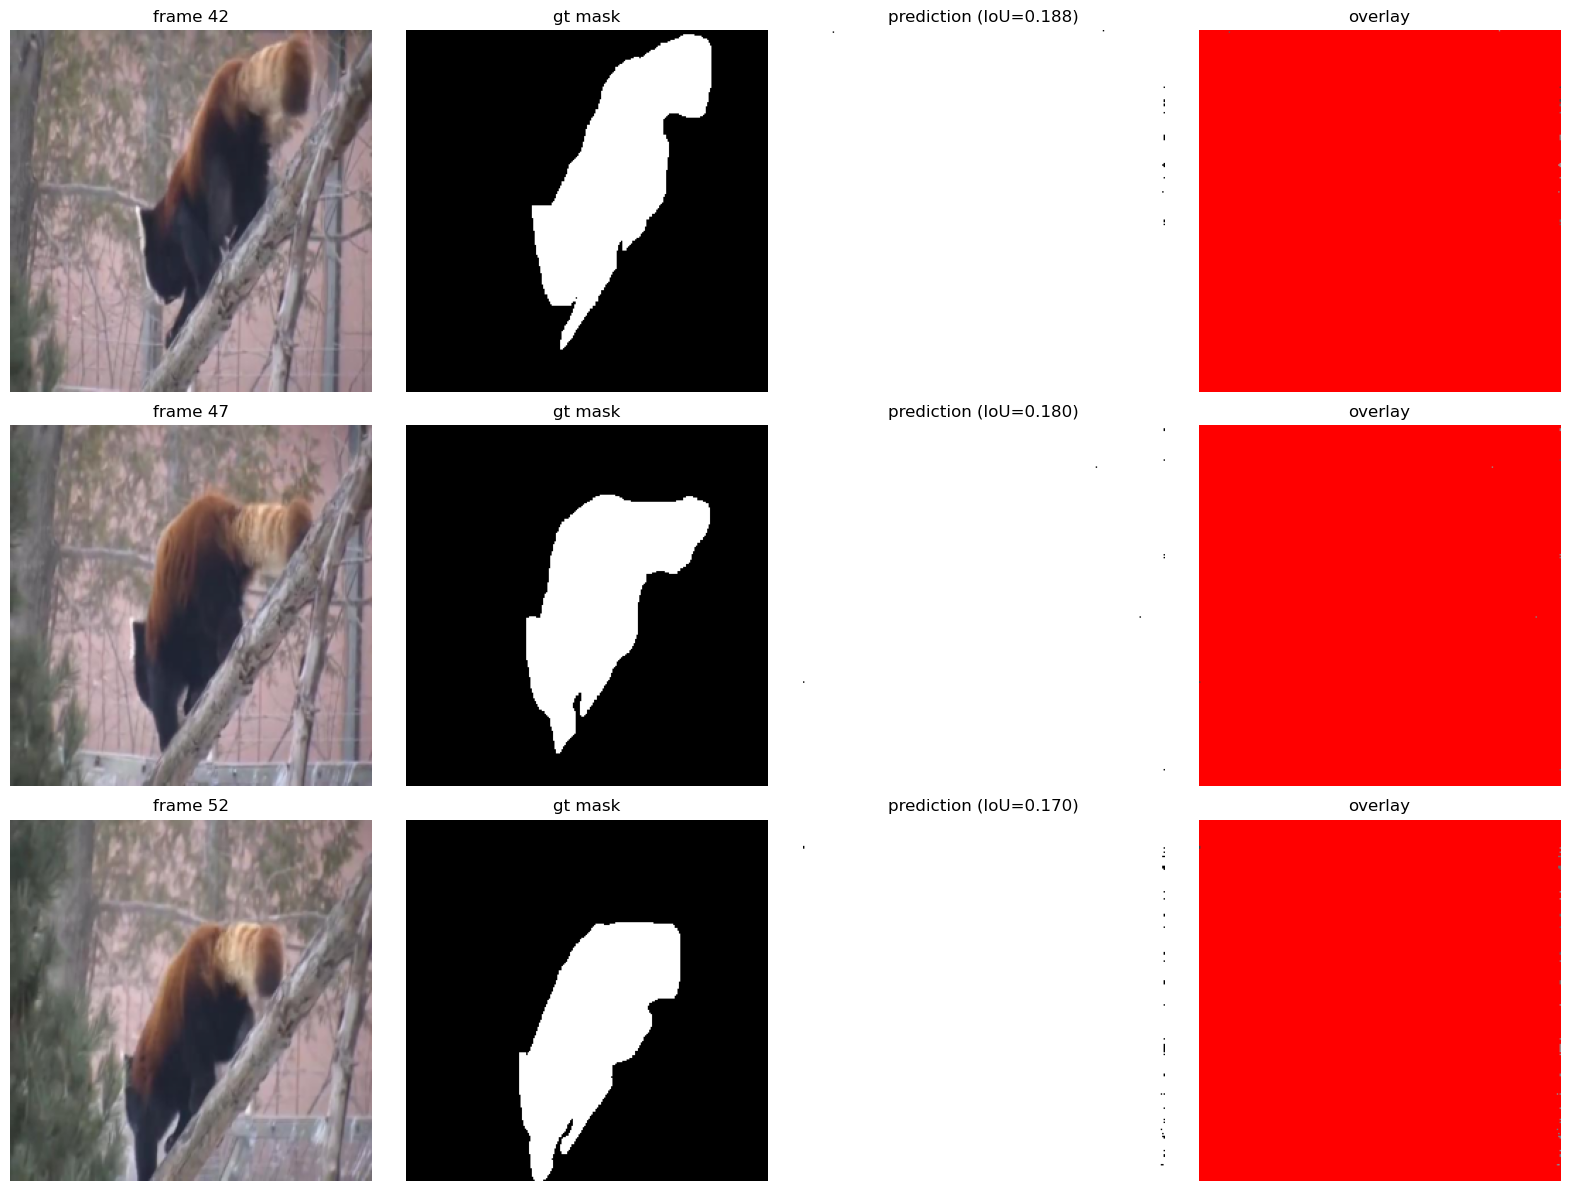

In [70]:
visualize_result(results, indices=[42, 47, 52], save_path='zero_shot_inference_result_2.png')

saved to zero_shot_inference_result_3.png


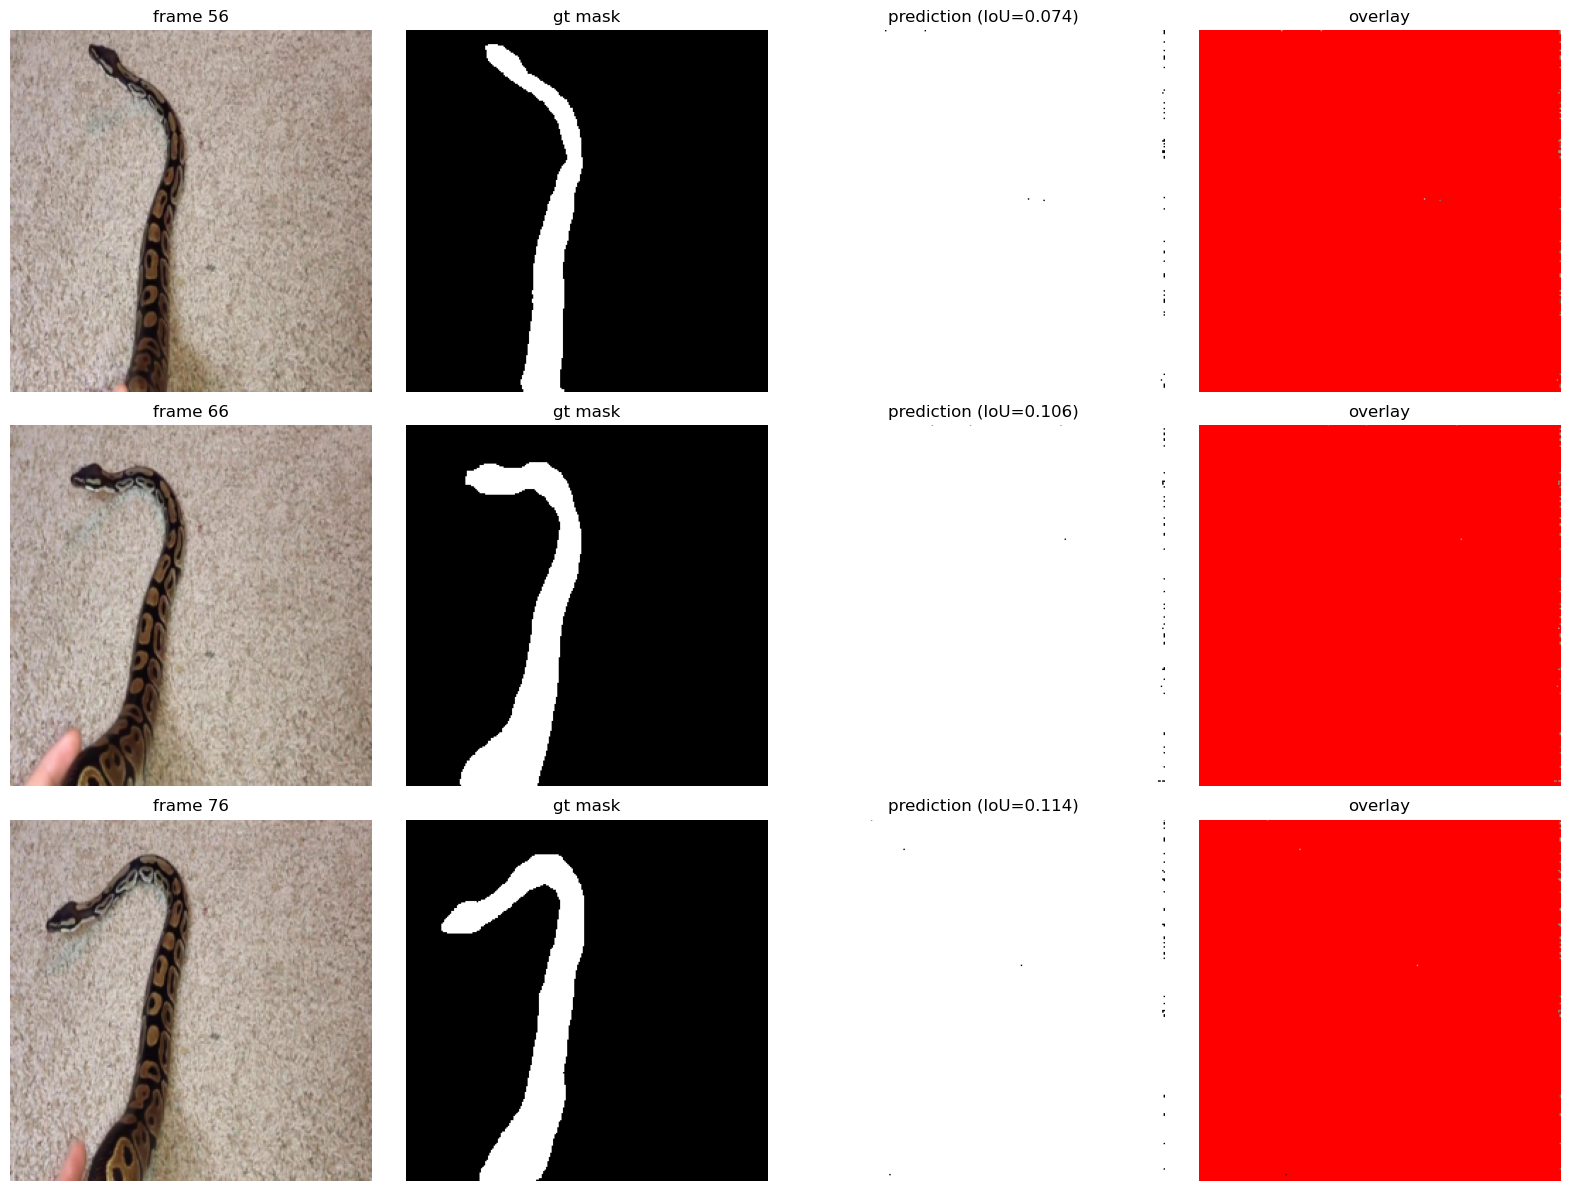

In [71]:
visualize_result(results, indices=[56, 66, 76], save_path='zero_shot_inference_result_3.png')

In [169]:
torch.mps.empty_cache()

In [172]:
model1.train()

for name, param in model1.encoder.named_parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
total = sum(p.numel() for p in model1.parameters())
print(f'learning parameters {trainable} out of {total}, {100 * trainable / total:.1f}%')

learning parameters 3151697 out of 24439505, 12.9%


In [73]:
def dice_loss(pred, target, eps=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()

_gt_fracs = []
for i in range(min(len(train_prev), 300)):
    _, _, m = train_prev[i]
    _gt_fracs.append(m.mean().item())
POS_WEIGHT = ((1 - np.mean(_gt_fracs)) / np.mean(_gt_fracs))
print(f'proportion of the object in train: {np.mean(_gt_fracs):.4f} -> POS_WEIGHT={POS_WEIGHT:.2f}')

def weighted_bce(pred, target, pos_weight=POS_WEIGHT):
    weights = torch.where(target > 0.5,
                           torch.full_like(target, pos_weight),
                           torch.ones_like(target))
    return torch.nn.functional.binary_cross_entropy(pred, target, weight=weights)

def combined_loss(pred, target):
    return weighted_bce(pred, target) + dice_loss(pred, target)

proportion of the object in train: 0.1306 -> POS_WEIGHT=6.65


In [173]:
BATCH_SIZE = 16
EPOCHS = 25
LR = 1e-4
PATIENCE = 5

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'using: {device}')

train_loader = DataLoader(train_prev, batch_size=BATCH_SIZE, shuffle=True)
valid_loader_train = DataLoader(valid_prev, batch_size=BATCH_SIZE, shuffle=False)

ENCODER_LR = LR / 10
encoder_params = [p for n, p in model1.named_parameters() if p.requires_grad and n.startswith('encoder.')]
other_params = [p for n, p in model1.named_parameters() if p.requires_grad and not n.startswith('encoder.')]

param_groups = [{'params': other_params, 'lr': LR}]
if len(encoder_params) > 0:
    param_groups.append({'params': encoder_params, 'lr': ENCODER_LR})

optimizer = torch.optim.Adam(param_groups)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

model1.to(device)

history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

for epoch in range(EPOCHS):
    epoch_start = time.time()
    model1.train()
    running_loss = 0.0
    for img, prev_mask, mask in train_loader:
        img, prev_mask, mask = img.to(device), prev_mask.to(device), mask.to(device)
        inp = torch.cat([img, prev_mask], dim=1)

        optimizer.zero_grad()
        out = model1(inp)
        loss = combined_loss(out, mask)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * img.size(0)

    train_loss = running_loss / len(train_prev)

    model1.eval()
    val_running_loss = 0.0
    val_ious, val_dices = [], []
    with torch.no_grad():
        for img, prev_mask, mask in valid_loader_train:
            img, prev_mask, mask = img.to(device), prev_mask.to(device), mask.to(device)
            inp = torch.cat([img, prev_mask], dim=1)
            out = model1(inp)
            loss = combined_loss(out, mask)
            val_running_loss += loss.item() * img.size(0)

            pred_np = (out > 0.5).float().cpu().numpy()
            gt_np = mask.cpu().numpy()
            for p, g in zip(pred_np, gt_np):
                m = calculate_metrics(p, g)
                val_ious.append(m['iou'])
                val_dices.append(m['dice'])

    val_loss = val_running_loss / len(valid_prev)
    val_iou = np.mean(val_ious)
    val_dice = np.mean(val_dices)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)

    epoch_time = time.time() - epoch_start
    print(f'epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | '
          f'val_loss={val_loss:.4f} | val_IoU={val_iou:.4f} | val_Dice={val_dice:.4f} | '
          f'{epoch_time:.1f}s')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in model1.state_dict().items()}
        torch.save(best_state, 'unet_prev_finetuned_best.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'early stopping on {epoch + 1}')
            break

if best_state is not None:
    model1.load_state_dict(best_state)
model1.eval()
print('loaded best weights')

using: mps
epoch 1/25 | train_loss=1.3146 | val_loss=1.0158 | val_IoU=0.4485 | val_Dice=0.6007 | 114.3s
epoch 2/25 | train_loss=1.0334 | val_loss=0.7563 | val_IoU=0.5900 | val_Dice=0.7306 | 110.3s
epoch 3/25 | train_loss=0.8886 | val_loss=0.6734 | val_IoU=0.6160 | val_Dice=0.7507 | 110.5s
epoch 4/25 | train_loss=0.8131 | val_loss=0.6352 | val_IoU=0.6068 | val_Dice=0.7280 | 111.7s
epoch 5/25 | train_loss=0.7403 | val_loss=0.5885 | val_IoU=0.6118 | val_Dice=0.7423 | 122.5s
epoch 6/25 | train_loss=0.7099 | val_loss=0.4716 | val_IoU=0.7017 | val_Dice=0.8157 | 123.6s
epoch 7/25 | train_loss=0.6774 | val_loss=0.4883 | val_IoU=0.7043 | val_Dice=0.8150 | 129.5s
epoch 8/25 | train_loss=0.6248 | val_loss=0.5221 | val_IoU=0.6780 | val_Dice=0.7961 | 128.9s
epoch 9/25 | train_loss=0.5870 | val_loss=0.5623 | val_IoU=0.6260 | val_Dice=0.7551 | 131.2s
epoch 10/25 | train_loss=0.5360 | val_loss=0.4508 | val_IoU=0.7202 | val_Dice=0.8269 | 134.1s
epoch 11/25 | train_loss=0.5128 | val_loss=0.4624 | val_Io

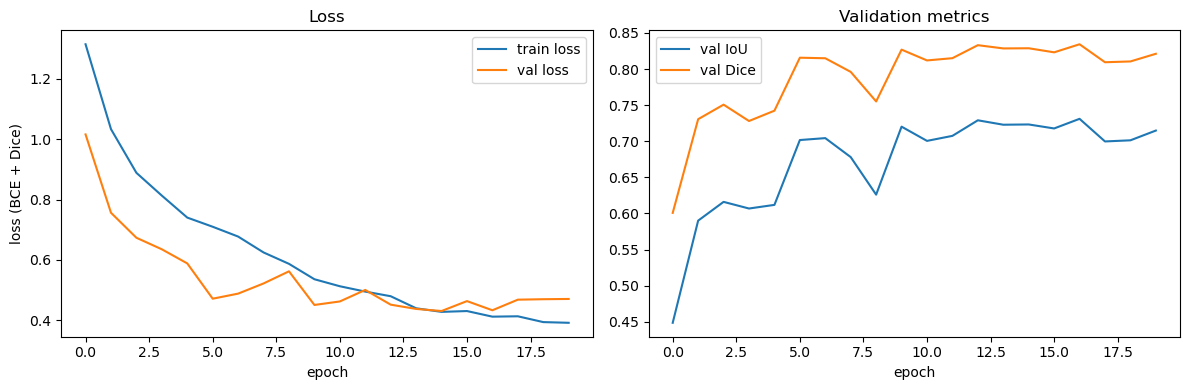

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train loss')
axes[0].plot(history['val_loss'], label='val loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss (BCE + Dice)')
axes[0].legend()
axes[0].set_title('Loss')

axes[1].plot(history['val_iou'], label='val IoU')
axes[1].plot(history['val_dice'], label='val Dice')
axes[1].set_xlabel('epoch')
axes[1].legend()
axes[1].set_title('Validation metrics')

plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

In [176]:
model1.eval()
test_loader_ft = DataLoader(valid_prev, batch_size=1, shuffle=False)
results_ft = []
prev_mask_pred = None
video_idx = -1
frame_idx_in_video = 0

for idx, (img, prev_mask, mask_gt) in enumerate(test_loader_ft):
    img_np = img.squeeze().permute(1, 2, 0).numpy()
    mask_gt_np = mask_gt.squeeze().numpy()

    if (prev_mask == 0).all().item():
        prev_mask_pred = mask_gt_np
        video_idx += 1
        frame_idx_in_video = 0

    prev_mask_pred = predict_mask(model1, img_np, prev_mask_pred,
                             transform_img=transform_img, transform_mask=transform_mask,
                             device=device)

    save_frame('baseline', video_idx, frame_idx_in_video, img_np, prev_mask_pred)
    frame_idx_in_video += 1

    results_ft.append({
        'idx': idx,
        'img': img_np,
        'prev_mask': prev_mask,
        'mask_gt': mask_gt_np,
        'mask_pred': prev_mask_pred
    })

print(f"processed {len(results_ft)} frames")

all_metrics_ft = []
for res in results_ft:
    metrics = calculate_metrics(res['mask_pred'], res['mask_gt'])
    all_metrics_ft.append(metrics)

mean_iou_ft = np.mean([m['iou'] for m in all_metrics_ft])
mean_dice_ft = np.mean([m['dice'] for m in all_metrics_ft])
mean_acc_ft = np.mean([m['accuracy'] for m in all_metrics_ft])
print('after fine-tuning:')
print(f"mean IoU: {mean_iou_ft:.4f}  (zero-shot before {mean_iou:.4f})")
print(f"mean Dice: {mean_dice_ft:.4f}  (zero-shot before {mean_dice:.4f})")
print(f"mean Pixel Accuracy: {mean_acc_ft:.4f}  (zero-shot before {mean_acc:.4f})")

processed 200 frames
after fine-tuning:
mean IoU: 0.2221  (zero-shot before 0.1152)
mean Dice: 0.3134  (zero-shot before 0.1990)
mean Pixel Accuracy: 0.8685  (zero-shot before 0.1156)


saved to after_tuning_result_1.png


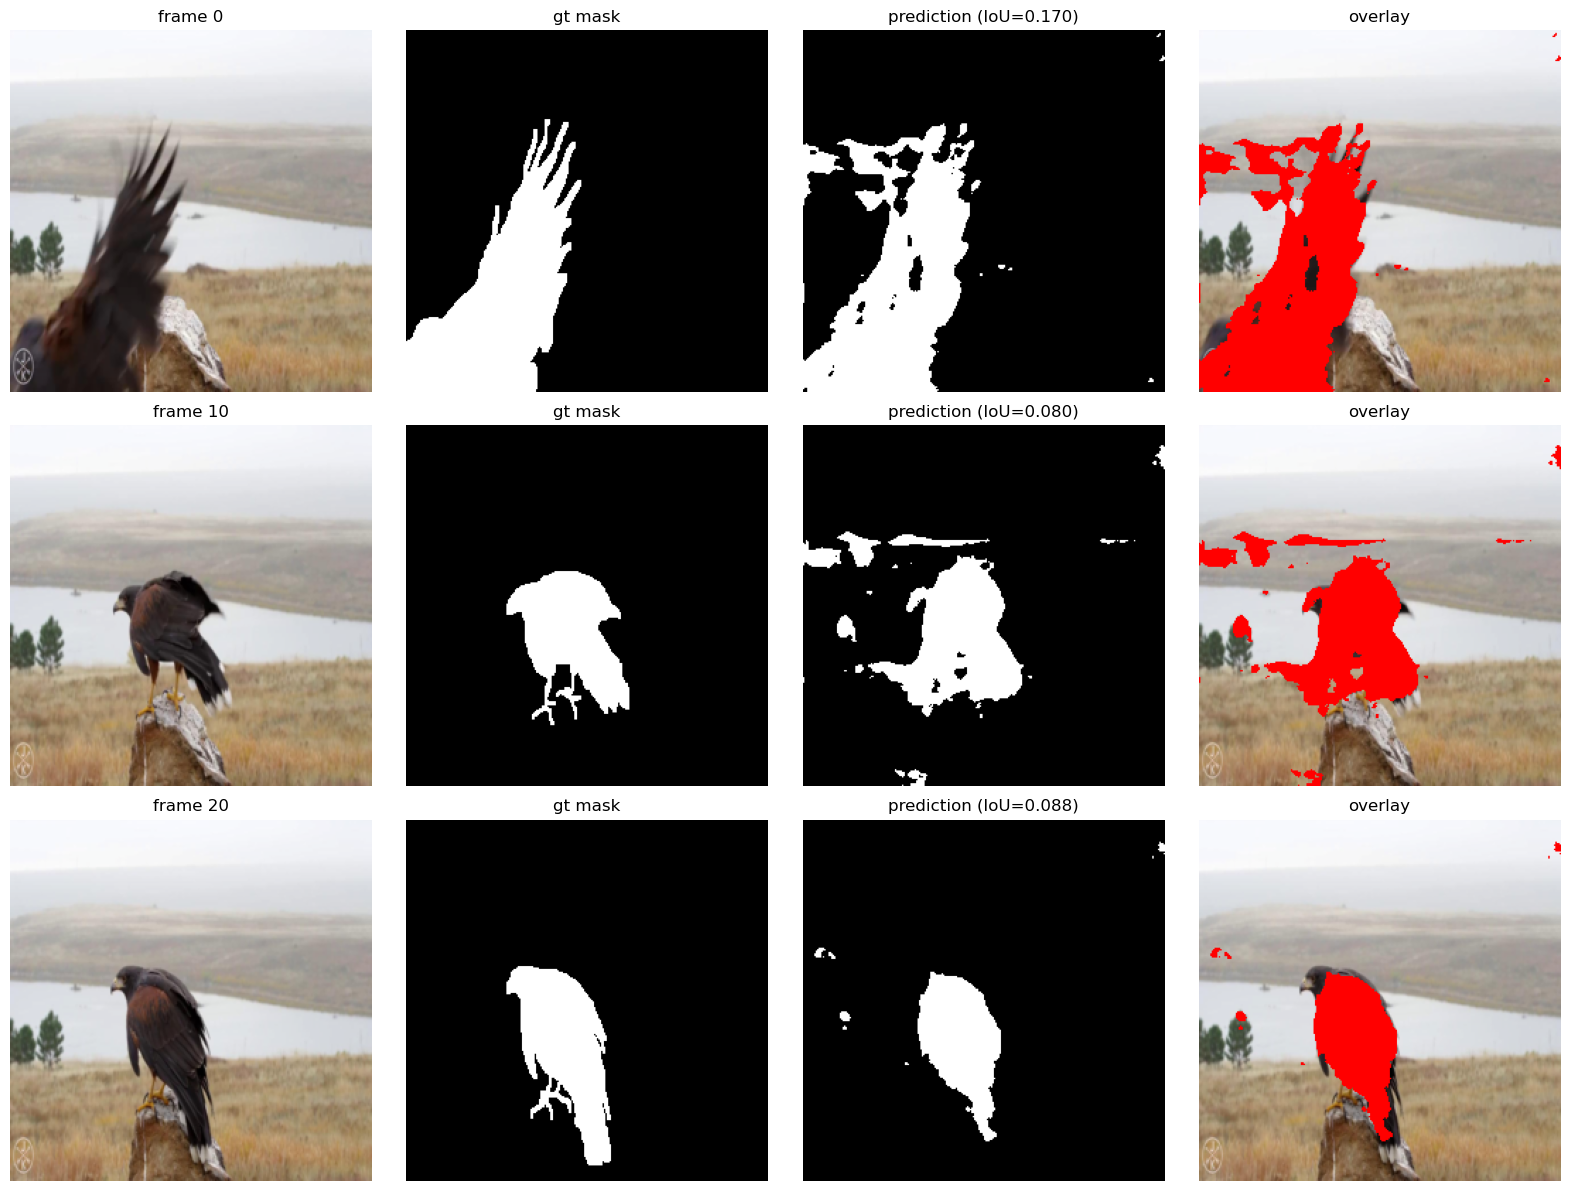

In [177]:
visualize_result(results_ft, indices=[0, 10, 20], save_path='after_tuning_result_1.png')

saved to zero_shot_inference_result_2.png


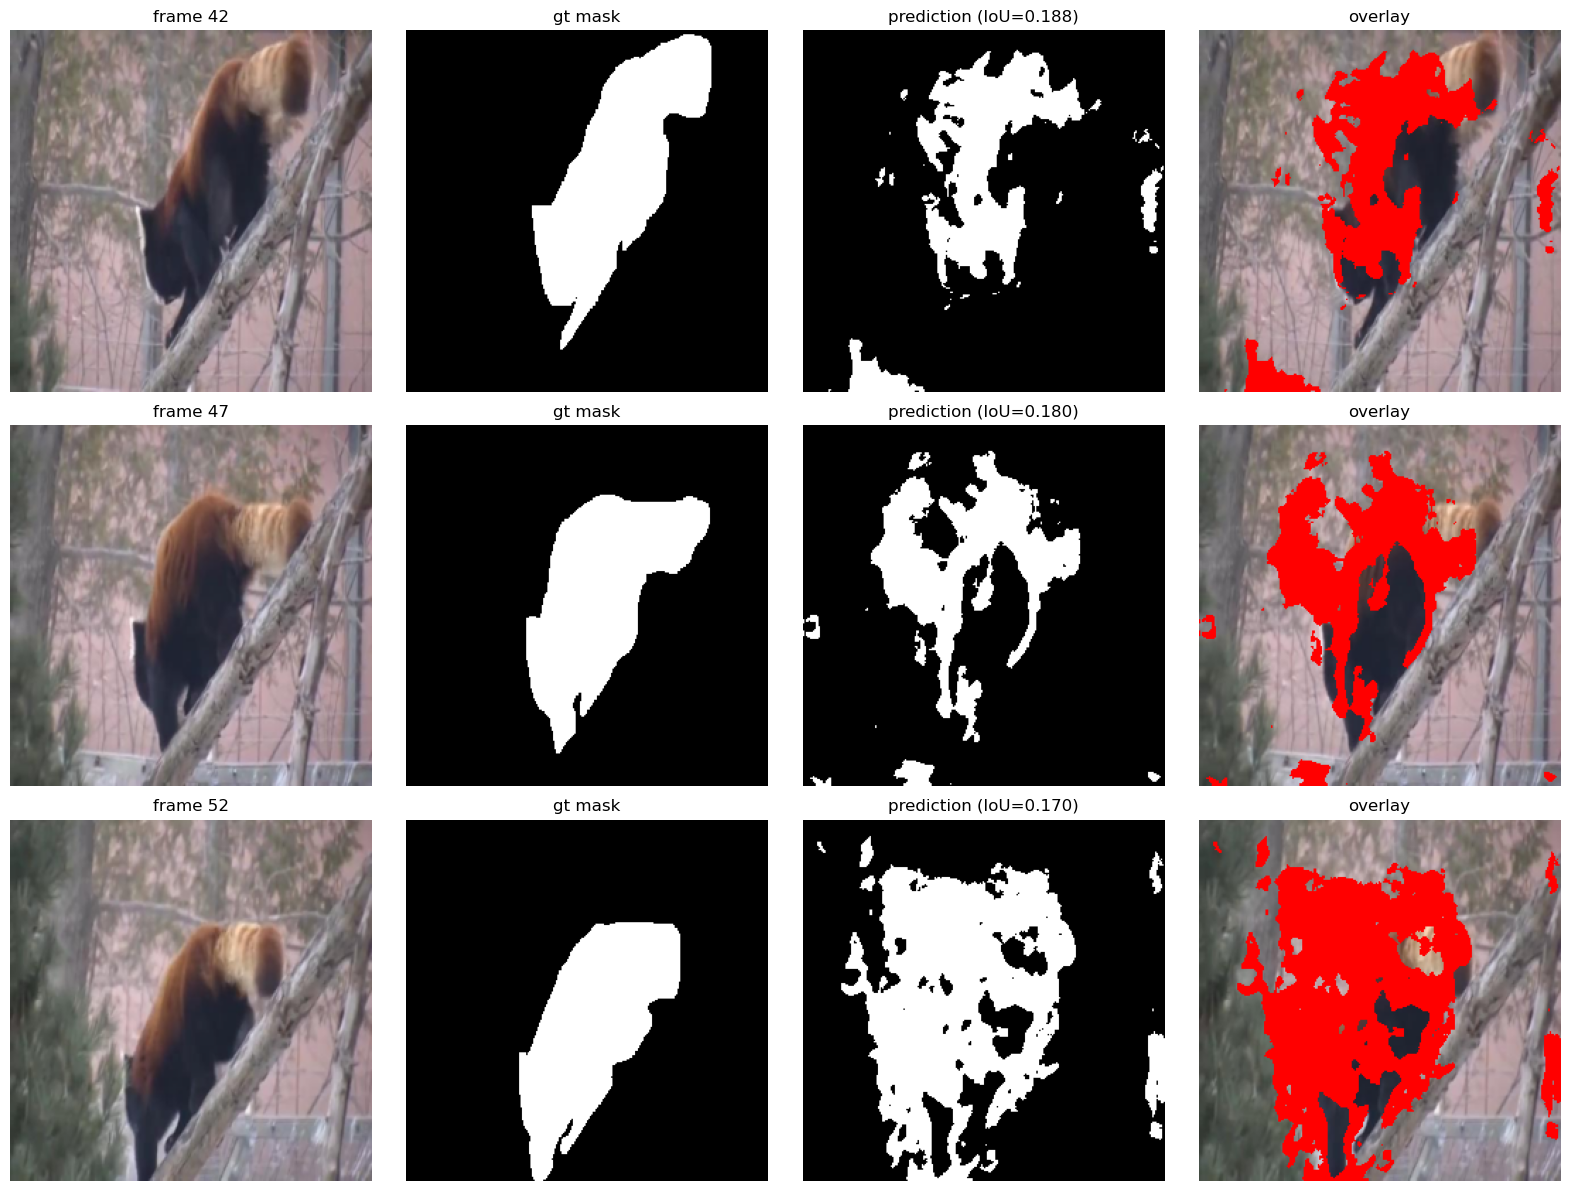

In [178]:
visualize_result(results_ft, indices=[42, 47, 52], save_path='zero_shot_inference_result_2.png')

saved to zero_shot_inference_result_3.png


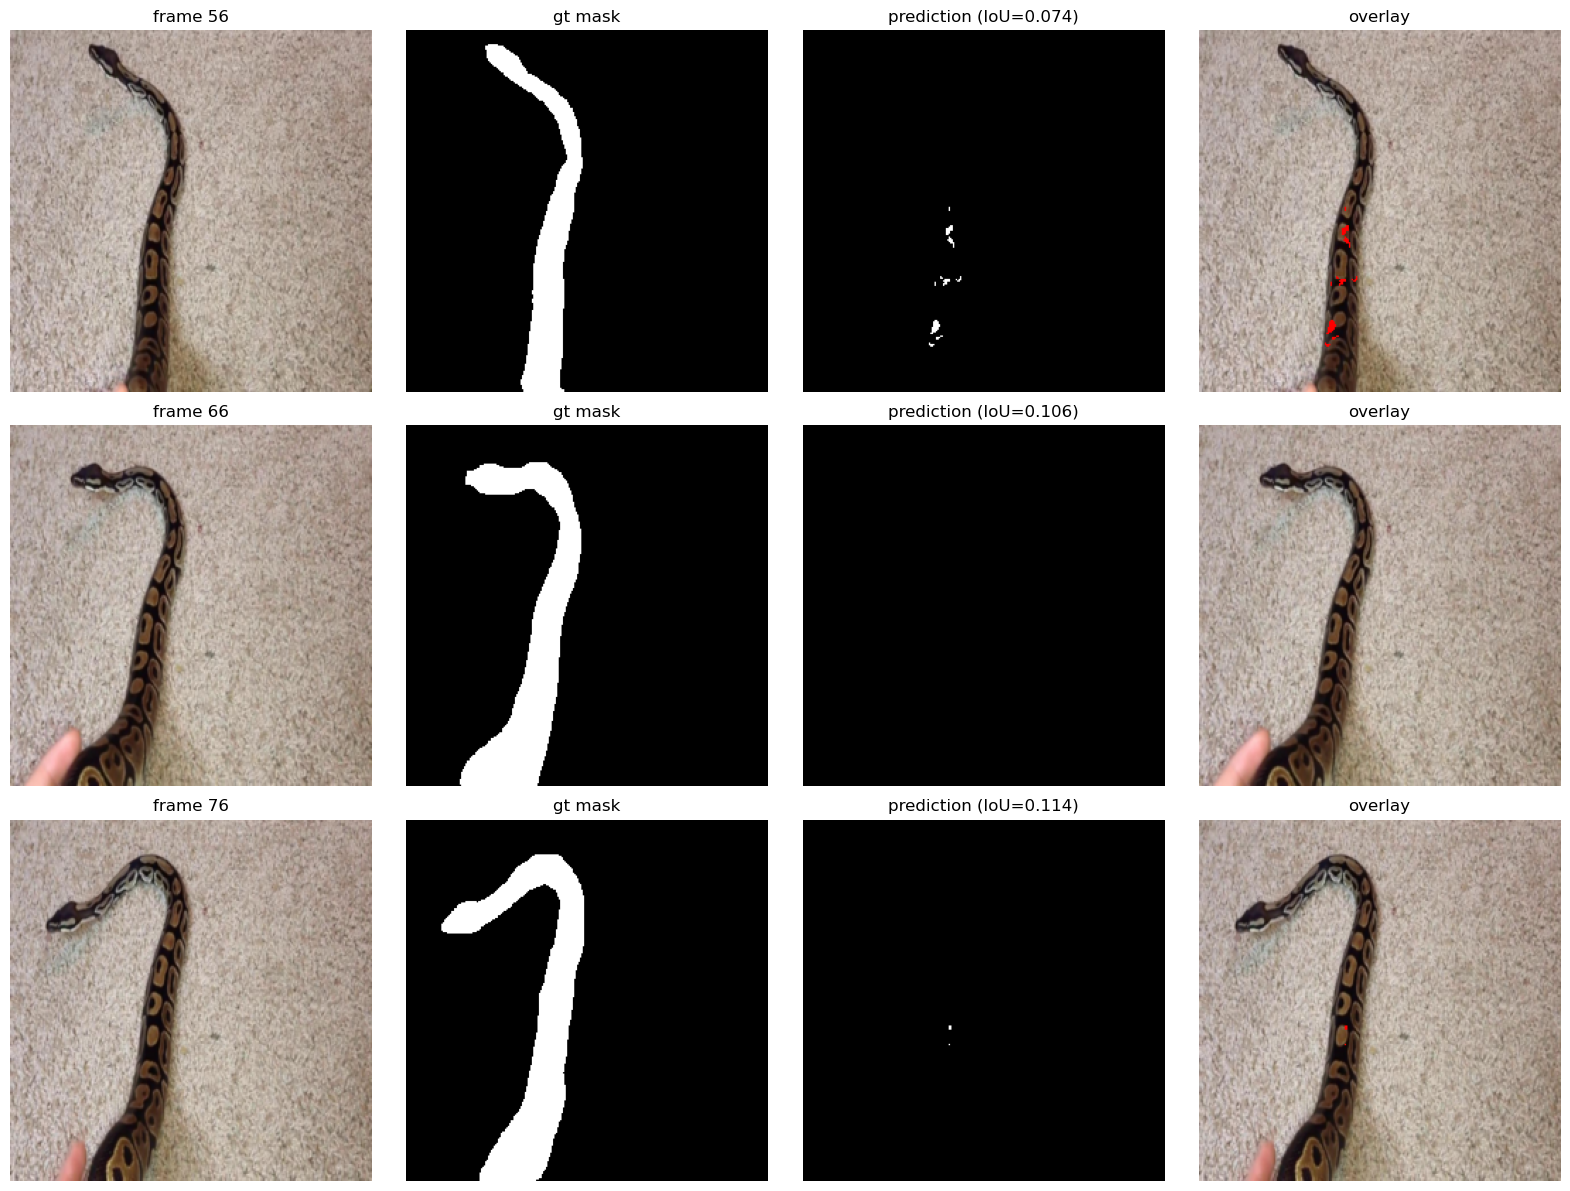

In [179]:
visualize_result(results_ft, indices=[56, 66, 76], save_path='zero_shot_inference_result_3.png')

In [180]:
def foreground_fraction(mask, thresh=0.5):
    return float((mask > thresh).mean())

gt_frac = np.mean([foreground_fraction(r['mask_gt'], 0.5) for r in results])
zs_frac = np.mean([foreground_fraction(r['mask_pred'], 0.5) for r in results])
ft_frac = np.mean([foreground_fraction(r['mask_pred'], 0.5) for r in results_ft])

print(f'actual shate of object pixels (GT): {gt_frac:.4f}')
print(f'share of pixels predicted as object:')
print(f'zero-shot: {zs_frac:.4f} ({zs_frac/gt_frac:.1f}x greater GT)' if zs_frac > gt_frac
      else f'zero-shot: {zs_frac:.4f} ({gt_frac/zs_frac:.1f}x less GT)')
print(f'after fine-tuning: {ft_frac:.4f} ({ft_frac/gt_frac:.1f}x greater GT)' if ft_frac > gt_frac
      else f'after fine-tuning: {ft_frac:.4f}  ({gt_frac/ft_frac:.1f}x less GT)')

empty_frac_ft = np.mean([foreground_fraction(r['mask_pred'], 0.5) < 0.001 for r in results_ft])
empty_frac_zs = np.mean([foreground_fraction(r['mask_pred'], 0.5) < 0.001 for r in results])
print()
print(f'share of frames with almost empty mask (<0.1% pixels):')
print(f'zero-shot: {100*empty_frac_zs:.1f}%')
print(f'after fine-tuning: {100*empty_frac_ft:.1f}%')

actual shate of object pixels (GT): 0.1151
share of pixels predicted as object:
zero-shot: 0.9995 (8.7x greater GT)
after fine-tuning: 0.1126  (1.0x less GT)

share of frames with almost empty mask (<0.1% pixels):
zero-shot: 0.0%
after fine-tuning: 7.5%


In [27]:
def load_raft(device):
    weights = Raft_Small_Weights.DEFAULT
    model = raft_small(weights=weights, progress=False).to(device)
    model.eval()
    return model

In [115]:
def pil_to_raft_tensor(img):
    t = TF.to_tensor(img.convert('RGB')) * 255.0
    return t.unsqueeze(0).to(device)
def warp_mask_with_flow(prev_mask_np, frame1, frame2, raft_model, device):
    H, W = prev_mask_np.shape

    t1 = pil_to_raft_tensor(frame1)
    t2 = pil_to_raft_tensor(frame2)

    _, _, h, w = t1.shape
    pad_h = (8 - h % 8) % 8
    pad_w = (8 - w % 8) % 8
    if pad_h > 0 or pad_w > 0:
        t1 = F.pad(t1, [0, pad_w, 0, pad_h])
        t2 = F.pad(t2, [0, pad_w, 0, pad_h])

    with torch.no_grad():
        flow_predictions = raft_model(t1, t2)
        flow = flow_predictions[-1]

    flow = flow[:, :, :h, :w]

    _, _, fH, fW = flow.shape
    if (fH, fW) != (H, W):
        flow = F.interpolate(flow, size=(H, W), mode='bilinear', align_corners=True)
        flow[:, 0] *= W / fW
        flow[:, 1] *= H / fH

    grid_y, grid_x = torch.meshgrid(
        torch.arange(H, device=device, dtype=torch.float32),
        torch.arange(W, device=device, dtype=torch.float32),
        indexing='ij'
    )
    sample_x = (grid_x + flow[0, 0])
    sample_y = (grid_y + flow[0, 1])
    sample_x = (sample_x / (W - 1)) * 2 - 1
    sample_y = (sample_y / (H - 1)) * 2 - 1

    grid = torch.stack([sample_x, sample_y], dim=-1).unsqueeze(0)
    mask_tensor = torch.from_numpy(prev_mask_np).float().unsqueeze(0).unsqueeze(0).to(device)
    warped = F.grid_sample(mask_tensor, grid, mode='bilinear',
                           padding_mode='zeros', align_corners=True)
    warped_np = warped.squeeze().cpu().numpy()
    warped_np = (warped_np > 0.5).astype(np.float32)
    return warped_np
    
def get_video_frame_paths(dataset):
    return [(item[0], item[1]) for item in dataset.data]

In [29]:
def create_flow(path_train, device=None):
    if device is None:
        device = torch.device(
            'mps' if torch.backends.mps.is_available() else
            'cuda' if torch.cuda.is_available() else 'cpu'
        )
    raft = load_raft(device)

    return raft, device

In [32]:
def precompute_train_flow_masks(path_train, length, flow_masks_dir,
                                 raft_model, raft_device,
                                 transform_img, transform_mask,
                                 seed=10):

    _ = YVOSDataset(
        path=path_train,
        length=length,
        transform_img=transform_img,
        transform_mask=transform_mask,
        shuffle=True,
        seed=seed,
        corrupt_prev_mask_aug=False,
        use_flow_mask=True,
        save_flow_masks=True,
        flow_masks_dir=flow_masks_dir,
        raft_model=raft_model,
        raft_device=raft_device,
    )

In [116]:
FLOW_MASKS_DIR = '../data/YoutubeVos/train_flow_masks'
raft_model, raft_device = create_flow(
    path_train='../data/YoutubeVos/train'
)

precompute_train_flow_masks(
    path_train='../data/YoutubeVos/train',
    length=4000,
    flow_masks_dir=FLOW_MASKS_DIR,
    raft_model=raft_model,
    raft_device=raft_device,
    transform_img=transform_img,
    transform_mask=transform_mask,
    seed=10,
)

train_flow = YVOSDataset(
    path='../data/YoutubeVos/train',
    length=4000,
    transform_img=transform_img,
    transform_mask=transform_mask,
    shuffle=True, seed=10,
    corrupt_prev_mask_aug=True,
    use_flow_mask=True,
    save_flow_masks=True,    
    flow_masks_dir=FLOW_MASKS_DIR,
)

valid_flow = YVOSDataset(
    path='../data/YoutubeVos/valid',
    length=200,
    transform_img=transform_img,
    transform_mask=transform_mask,
    shuffle=False,
    use_flow_mask=True,
    save_flow_masks=False,
    raft_model=raft_model,
    raft_device=raft_device,
)

  [100/4000] processed=100 skiped=0 ~17.7 mins more
  [200/4000] processed=200 skiped=0 ~26.8 mins more
  [300/4000] processed=300 skiped=0 ~22.7 mins more
  [400/4000] processed=400 skiped=0 ~22.2 mins more
  [500/4000] processed=500 skiped=0 ~20.2 mins more
  [600/4000] processed=600 skiped=0 ~18.9 mins more
  [700/4000] processed=700 skiped=0 ~21.8 mins more
  [800/4000] processed=800 skiped=0 ~21.4 mins more
  [900/4000] processed=900 skiped=0 ~24.8 mins more
  [1000/4000] processed=1000 skiped=0 ~22.9 mins more
  [1100/4000] processed=1100 skiped=0 ~21.3 mins more
  [1200/4000] processed=1200 skiped=0 ~20.0 mins more
  [1300/4000] processed=1300 skiped=0 ~18.8 mins more
  [1400/4000] processed=1400 skiped=0 ~17.7 mins more
  [1500/4000] processed=1500 skiped=0 ~17.4 mins more
  [1600/4000] processed=1600 skiped=0 ~17.4 mins more
  [1700/4000] processed=1700 skiped=0 ~16.3 mins more
  [1800/4000] processed=1800 skiped=0 ~15.3 mins more
  [1900/4000] processed=1900 skiped=0 ~14.4 mi

In [122]:
model2 = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=4,
    classes=1,
    activation='sigmoid'
)

model2.eval()

device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f'model2 loaded to {device}')

model2 loaded to mps


In [118]:
video_frame_paths = get_video_frame_paths(valid_flow)

test_loader_flow = DataLoader(valid_flow, batch_size=1, shuffle=False)
results2 = []
mask_pred_prev = None 
prev_frame_pil = None 

for idx, (img, prev_mask, mask_gt) in enumerate(test_loader_flow):
    img_np = img.squeeze().permute(1, 2, 0).numpy()
    mask_gt_np = mask_gt.squeeze().numpy()

    path_img, path_prev_img = video_frame_paths[idx]
    curr_frame_pil = Image.open(path_img)

    if (prev_mask == 0).all().item():
        mask_pred_prev = mask_gt_np
        flow_input_mask = mask_pred_prev
    else:
        flow_input_mask = warp_mask_with_flow(
            mask_pred_prev.astype(np.float32),
            prev_frame_pil, curr_frame_pil,
            raft_model, raft_device
        )

    mask_pred = predict_mask(model2, img_np, flow_input_mask,
                             transform_img=transform_img, transform_mask=transform_mask)

    results2.append({
        'idx': idx,
        'img': img_np,
        'flow_mask': flow_input_mask,
        'mask_gt': mask_gt_np,
        'mask_pred': mask_pred
    })

    mask_pred_prev = mask_pred
    prev_frame_pil = curr_frame_pil

print(f"processed {len(results2)} frames")

all_metrics = []
for res in results2:
    metrics = calculate_metrics(res['mask_pred'], res['mask_gt'])
    all_metrics.append(metrics)

mean_iou = np.mean([metric['iou'] for metric in all_metrics])
mean_dice = np.mean([metric['dice'] for metric in all_metrics])
mean_acc = np.mean([metric['accuracy'] for metric in all_metrics])
print('Zero-shot inference (with flow-warped prev prediction):')
print(f"mean IoU: {mean_iou:.4f}")
print(f"mean Dice: {mean_dice:.4f}")
print(f"mean Pixel Accuracy: {mean_acc:.4f}")

processed 200 frames
Zero-shot inference (with flow-warped prev prediction):
mean IoU: 0.1171
mean Dice: 0.2019
mean Pixel Accuracy: 0.1336


In [123]:
model2.train()

for name, param in model2.encoder.named_parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model2.parameters() if p.requires_grad)
total = sum(p.numel() for p in model2.parameters())
print(f'learning parameters {trainable} out of {total}, {100 * trainable / total:.1f}%')

learning parameters 3151697 out of 24439505, 12.9%


In [124]:
BATCH_SIZE = 16
EPOCHS = 25
LR = 1e-4
PATIENCE = 5

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'using: {device}')

train_loader_flow = DataLoader(train_flow, batch_size=BATCH_SIZE, shuffle=True)
valid_loader_flow = DataLoader(valid_flow, batch_size=BATCH_SIZE, shuffle=False)

ENCODER_LR = LR / 10
encoder_params = [p for n, p in model2.named_parameters() if p.requires_grad and n.startswith('encoder.')]
other_params = [p for n, p in model2.named_parameters() if p.requires_grad and not n.startswith('encoder.')]

param_groups = [{'params': other_params, 'lr': LR}]
if len(encoder_params) > 0:
    param_groups.append({'params': encoder_params, 'lr': ENCODER_LR})

optimizer = torch.optim.Adam(param_groups)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

model2.to(device)

history_flow = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

for epoch in range(EPOCHS):
    epoch_start = time.time()
    model2.train()
    running_loss = 0.0
    for img, prev_mask, mask in train_loader_flow:
        img, prev_mask, mask = img.to(device), prev_mask.to(device), mask.to(device)
        inp = torch.cat([img, prev_mask], dim=1)

        optimizer.zero_grad()
        out = model2(inp)
        loss = combined_loss(out, mask)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * img.size(0)

    train_loss = running_loss / len(train_flow)

    model2.eval()
    val_running_loss = 0.0
    val_ious, val_dices = [], []
    with torch.no_grad():
        for img, prev_mask, mask in valid_loader_flow:
            img, prev_mask, mask = img.to(device), prev_mask.to(device), mask.to(device)
            inp = torch.cat([img, prev_mask], dim=1)
            out = model2(inp)
            loss = combined_loss(out, mask)
            val_running_loss += loss.item() * img.size(0)

            pred_np = (out > 0.5).float().cpu().numpy()
            gt_np = mask.cpu().numpy()
            for p, g in zip(pred_np, gt_np):
                m = calculate_metrics(p, g)
                val_ious.append(m['iou'])
                val_dices.append(m['dice'])

    val_loss = val_running_loss / len(valid_flow)
    val_iou = np.mean(val_ious)
    val_dice = np.mean(val_dices)

    scheduler.step(val_loss)

    history_flow['train_loss'].append(train_loss)
    history_flow['val_loss'].append(val_loss)
    history_flow['val_iou'].append(val_iou)
    history_flow['val_dice'].append(val_dice)

    epoch_time = time.time() - epoch_start
    print(f'epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} | '
          f'val_loss={val_loss:.4f} | val_IoU={val_iou:.4f} | val_Dice={val_dice:.4f} | '
          f'{epoch_time:.1f}s')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in model2.state_dict().items()}
        torch.save(best_state, 'unet_flow_finetuned_best.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'early stopping on {epoch + 1}')
            break

if best_state is not None:
    model2.load_state_dict(best_state)
model2.eval()
print('loaded best weights for model2 (flow)')

using: mps
epoch 1/25 | train_loss=1.2639 | val_loss=0.9141 | val_IoU=0.5544 | val_Dice=0.7005 | 222.3s
epoch 2/25 | train_loss=0.9405 | val_loss=0.7883 | val_IoU=0.5600 | val_Dice=0.7035 | 267.3s
epoch 3/25 | train_loss=0.7929 | val_loss=0.6588 | val_IoU=0.6044 | val_Dice=0.7374 | 131.5s
epoch 4/25 | train_loss=0.6961 | val_loss=0.6468 | val_IoU=0.6257 | val_Dice=0.7566 | 159.8s
epoch 5/25 | train_loss=0.6306 | val_loss=0.6704 | val_IoU=0.6731 | val_Dice=0.7834 | 164.2s
epoch 6/25 | train_loss=0.5842 | val_loss=0.6290 | val_IoU=0.6710 | val_Dice=0.7838 | 164.0s
epoch 7/25 | train_loss=0.5418 | val_loss=0.6508 | val_IoU=0.6479 | val_Dice=0.7698 | 182.3s
epoch 8/25 | train_loss=0.5029 | val_loss=0.5988 | val_IoU=0.6760 | val_Dice=0.7904 | 183.9s
epoch 9/25 | train_loss=0.4667 | val_loss=0.6402 | val_IoU=0.6502 | val_Dice=0.7720 | 175.4s
epoch 10/25 | train_loss=0.4401 | val_loss=0.6075 | val_IoU=0.6797 | val_Dice=0.7943 | 180.5s
epoch 11/25 | train_loss=0.4244 | val_loss=0.6113 | val_Io

In [181]:
model2.eval()
results2_ft = []
mask_pred_prev = None
prev_frame_pil = None
video_idx = -1
frame_idx_in_video = 0

for idx, (img, prev_mask, mask_gt) in enumerate(test_loader_flow):
    img_np = img.squeeze().permute(1, 2, 0).numpy()
    mask_gt_np = mask_gt.squeeze().numpy()
    path_img, path_prev_img = video_frame_paths[idx]
    curr_frame_pil = Image.open(path_img)

    if (prev_mask == 0).all().item():
        mask_pred_prev = mask_gt_np
        flow_input_mask = mask_pred_prev
        video_idx += 1
        frame_idx_in_video = 0
    else:
        flow_input_mask = warp_mask_with_flow(
            mask_pred_prev.astype(np.float32),
            prev_frame_pil, curr_frame_pil,
            raft_model, raft_device
        )

    mask_pred = predict_mask(model2, img_np, flow_input_mask,
                             transform_img=transform_img, transform_mask=transform_mask, device=device)

    save_frame('flow', video_idx, frame_idx_in_video, img_np, mask_pred,
               extra_mask=flow_input_mask, extra_tag='flowmask')
    
    frame_idx_in_video += 1

    results2_ft.append({
        'idx': idx, 'img': img_np, 'flow_mask': flow_input_mask,
        'mask_gt': mask_gt_np, 'mask_pred': mask_pred
    })
    mask_pred_prev = mask_pred
    prev_frame_pil = curr_frame_pil

print(f"processed {len(results2_ft)} frames")

all_metrics_2ft = [calculate_metrics(r['mask_pred'], r['mask_gt']) for r in results2_ft]
mean_iou_2ft = np.mean([m['iou'] for m in all_metrics_2ft])
mean_dice_2ft = np.mean([m['dice'] for m in all_metrics_2ft])
mean_acc_2ft = np.mean([m['accuracy'] for m in all_metrics_2ft])
print('after fine-tuning (with flow):')
print(f"mean IoU: {mean_iou_2ft:.4f} (baseline without flow: {mean_iou_ft:.4f})")
print(f"mean Dice: {mean_dice_2ft:.4f} (baseline without flow: {mean_dice_ft:.4f})")
print(f"mean Pixel Accuracy: {mean_acc_2ft:.4f} (baseline withoutflow: {mean_acc_ft:.4f})")

processed 200 frames
after fine-tuning (with flow):
mean IoU: 0.2066 (baseline without flow: 0.2221)
mean Dice: 0.3204 (baseline without flow: 0.3134)
mean Pixel Accuracy: 0.5862 (baseline withoutflow: 0.8685)


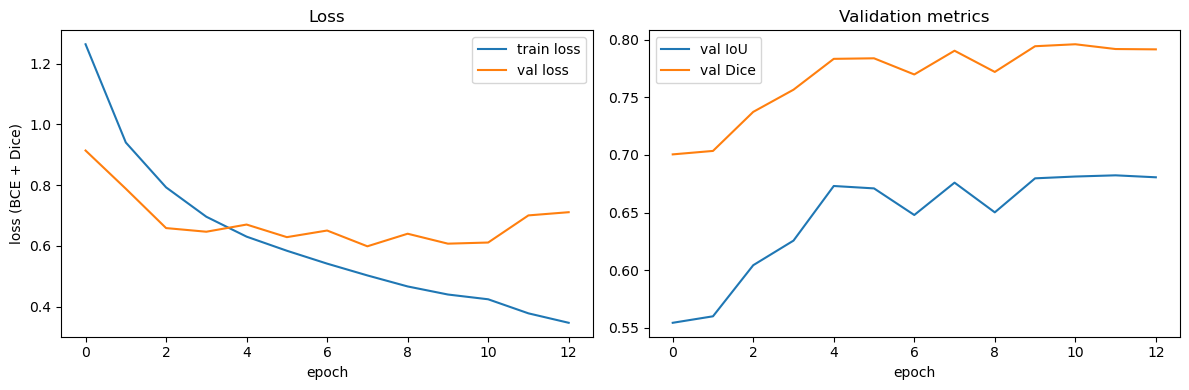

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_flow['train_loss'], label='train loss')
axes[0].plot(history_flow['val_loss'], label='val loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss (BCE + Dice)')
axes[0].legend()
axes[0].set_title('Loss')

axes[1].plot(history_flow['val_iou'], label='val IoU')
axes[1].plot(history_flow['val_dice'], label='val Dice')
axes[1].set_xlabel('epoch')
axes[1].legend()
axes[1].set_title('Validation metrics')

plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

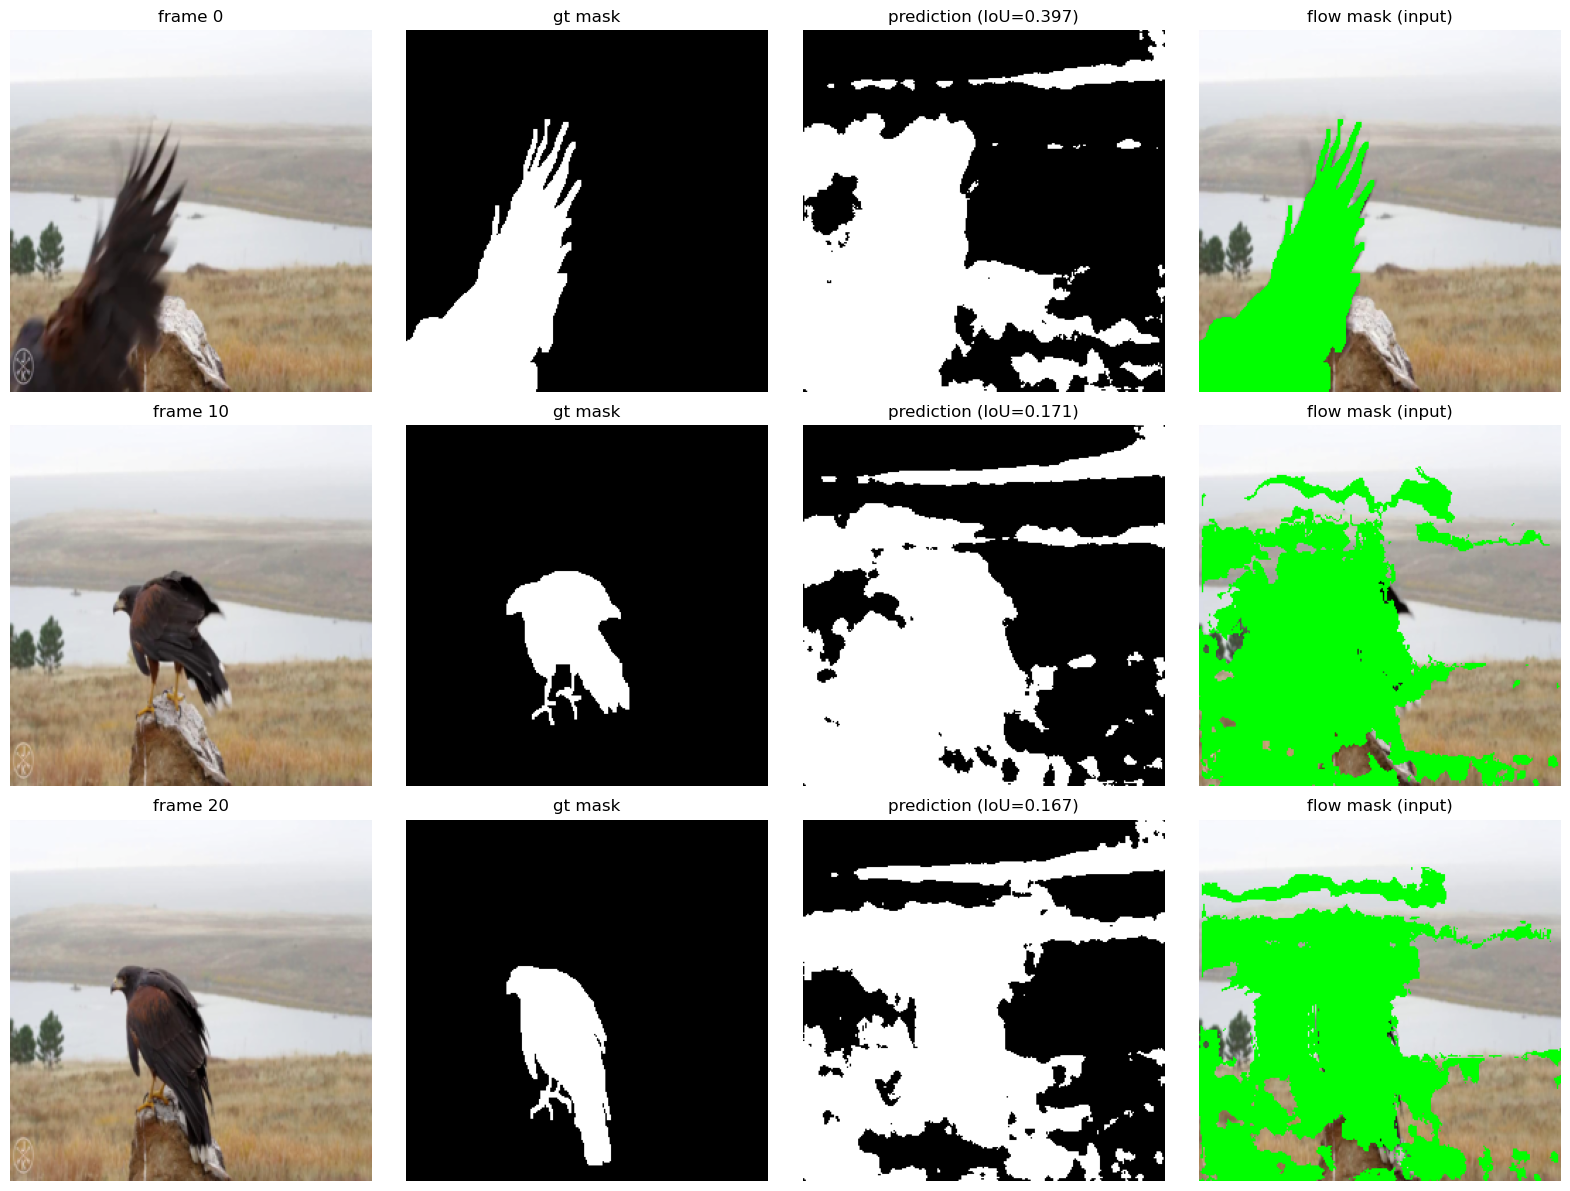

In [188]:
visualize_result(results2_ft, indices=[0, 10, 20], all_metrics=all_metrics_2ft, flow_mask_key='flow_mask')

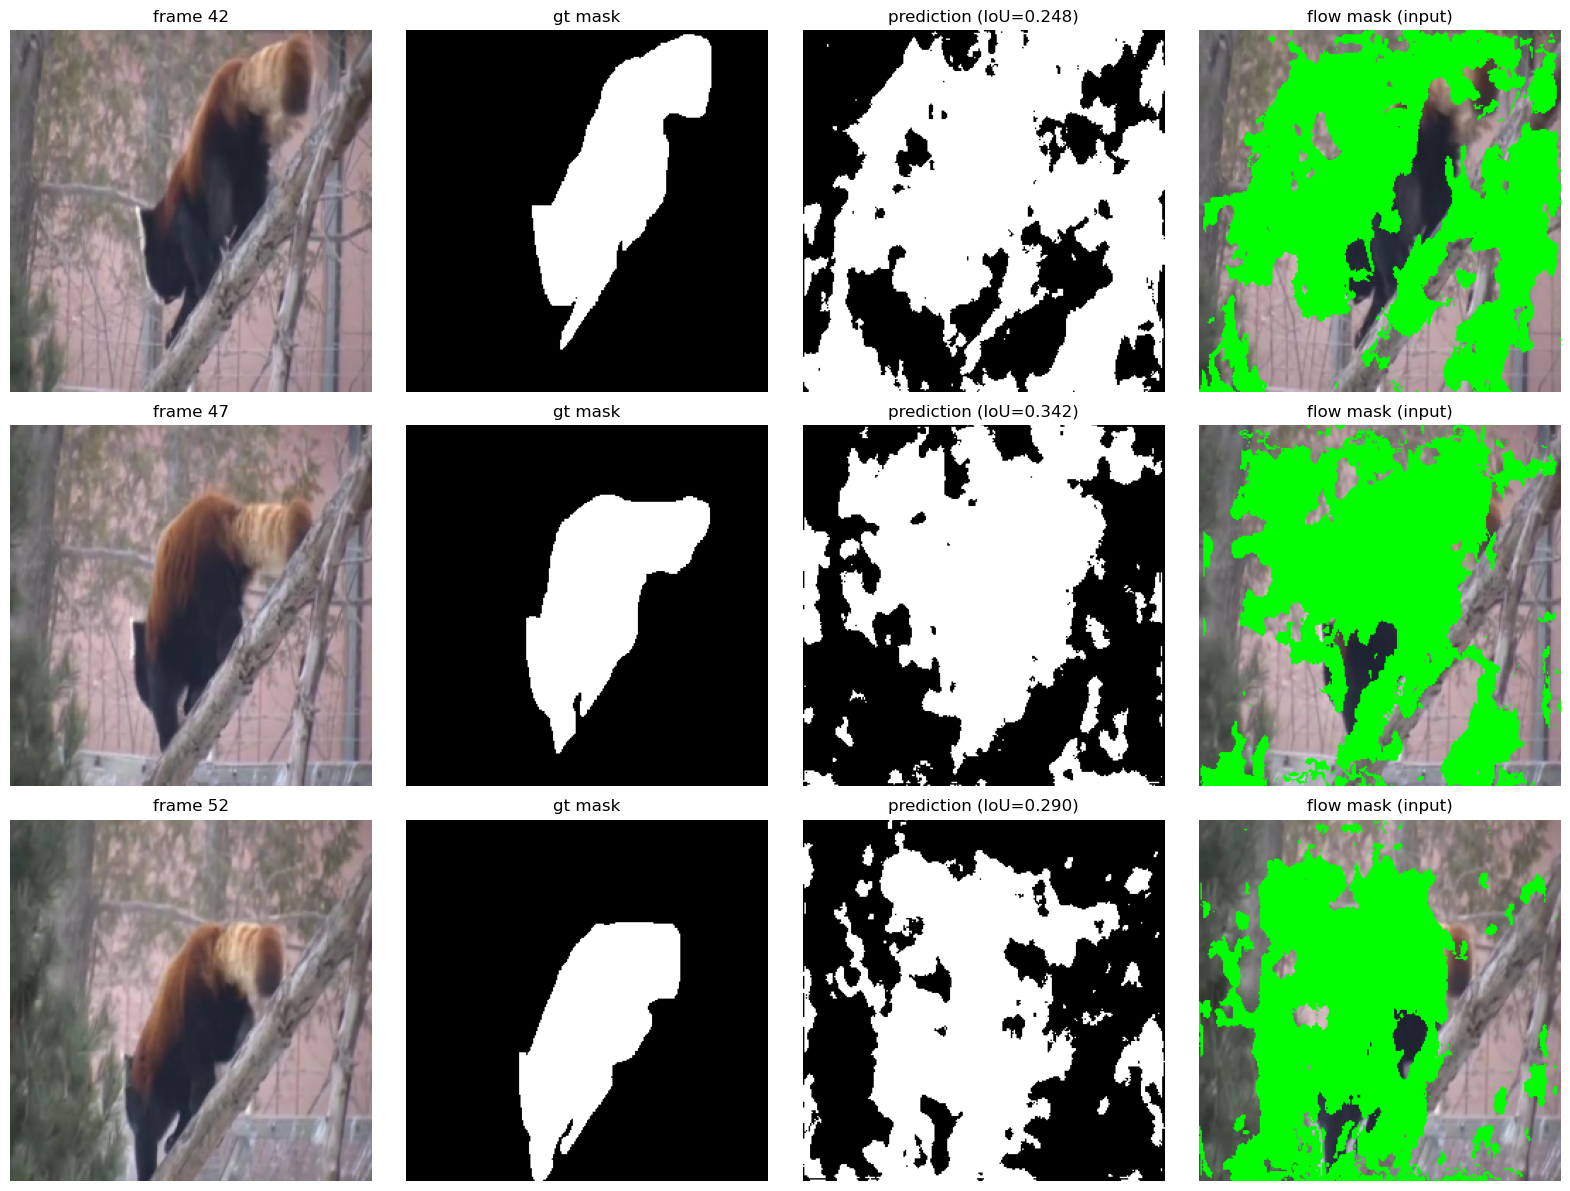

In [189]:
visualize_result(results2_ft, indices=[42, 47, 52], all_metrics=all_metrics_2ft, flow_mask_key='flow_mask')

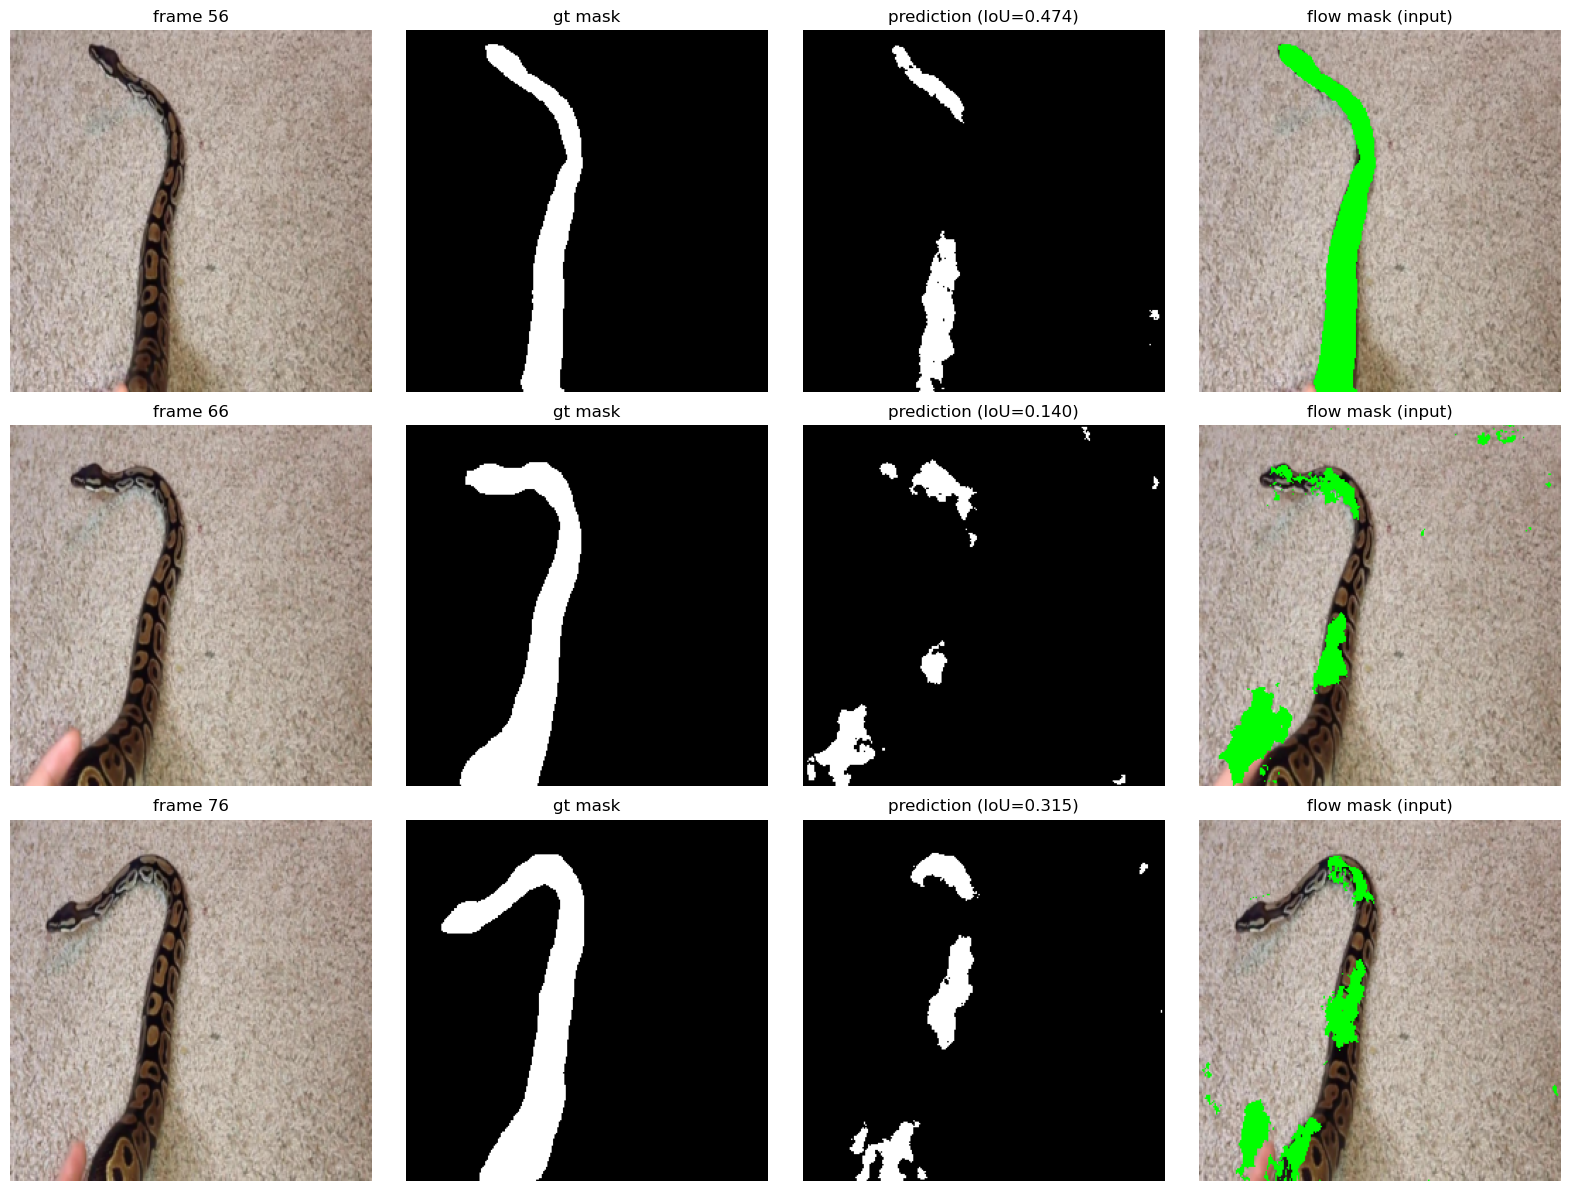

In [190]:
visualize_result(results2_ft, indices=[56, 66, 76], all_metrics=all_metrics_2ft, flow_mask_key='flow_mask')

In [183]:
def foreground_fraction(mask, thresh=0.5):
    return float((mask > thresh).mean())

gt_frac = np.mean([foreground_fraction(r['mask_gt'], 0.5) for r in results2])
zs_frac = np.mean([foreground_fraction(r['mask_pred'], 0.5) for r in results2])
ft_frac = np.mean([foreground_fraction(r['mask_pred'], 0.5) for r in results2_ft])

print(f'actual object share (GT):        {gt_frac:.4f}')
print(f'share predicted as object:')
print(f'zero-shot: {zs_frac:.4f}  ({zs_frac/gt_frac:.1f}x greater GT)' if zs_frac > gt_frac
      else f'zero-shot: {zs_frac:.4f}  ({gt_frac/zs_frac:.1f}x less GT)')
print(f'after fine-tuning: {ft_frac:.4f}  ({ft_frac/gt_frac:.1f}x greater GT)' if ft_frac > gt_frac
      else f'after fine-tuning: {ft_frac:.4f}  ({gt_frac/ft_frac:.1f}x less GT)')

empty_frac_ft = np.mean([foreground_fraction(r['mask_pred'], 0.5) < 0.001 for r in results2_ft])
empty_frac_zs = np.mean([foreground_fraction(r['mask_pred'], 0.5) < 0.001 for r in results2])
print()
print(f'share frames of almost empty mask (<0.1% pixels):')
print(f'zero-shot: {100*empty_frac_zs:.1f}%')
print(f'after fine-tuning: {100*empty_frac_ft:.1f}%')

actual object share (GT):        0.1151
share predicted as object:
zero-shot: 0.9811  (8.5x greater GT)
after fine-tuning: 0.4749  (4.1x greater GT)

share frames of almost empty mask (<0.1% pixels):
zero-shot: 0.0%
after fine-tuning: 0.0%


In [185]:
per_frame_iou_base = [calculate_metrics(r['mask_pred'], r['mask_gt'])['iou'] for r in results_ft]
per_frame_iou_flow = [calculate_metrics(r['mask_pred'], r['mask_gt'])['iou'] for r in results2_ft]

diff = np.array(per_frame_iou_flow) - np.array(per_frame_iou_base)
print(f'flow better on {np.sum(diff > 0.02)} frames out of {len(diff)}')
print(f'flow perform worse on {np.sum(diff < -0.02)} frames')
print(f'flow perform aproximately equal on {np.sum(np.abs(diff) <= 0.02)} frames')

worst_idx = np.argsort(diff)[:3]
best_idx = np.argsort(diff)[-3:]
print('flow perform way worse on frames', worst_idx.tolist())
print('flow perform way better on frames', best_idx.tolist())

flow better on 99 frames out of 200
flow perform worse on 85 frames
flow perform aproximately equal on 16 frames
flow perform way worse on frames [20, 19, 21]
flow perform way better on frames [82, 56, 87]
